<a href="https://colab.research.google.com/github/adnanmoe35/BSIP_Quiz3_Students/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — EDA, Pipeline Modeling, and Hyperparameter Tuning

You will:
1) Load the Titanic dataset
2) Do basic EDA using your `EDA` class in **ml_utils.py**
3) Build a scikit-learn **Pipeline** with preprocessing + feature engineering + model
4) Tune hyperparameters with **GridSearchCV**
5) Evaluate on a holdout test set


In [4]:
import os
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (8, 6)

# scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Custom utilities (YOU will edit ml_utils.py, and rename as eda_lastname.py)
import eda_Mohamed as ml_utils

## Part A — Clean data with EDA (warm-up)

Implement/extend `class EDA` inside **ml_utils.py**, then use it below.
Keep EDA simple: overview, missing values, target summary, and 1–2 plots.

In [6]:
from urllib.request import urlretrieve

f_path_2 = "data/titanic_train.csv"
url_2 = "https://github.com/AkeemSemper/ml_data/raw/main/titanic_train.csv"
os.makedirs("data", exist_ok=True)

if not os.path.exists(f_path_2):
    print("Downloading dataset...")
    urlretrieve(url_2, f_path_2)

df2 = pd.read_csv(f_path_2)
df3 = pd.read_csv(f_path_2)  # kept intentionally (per assignment instruction)

df = df2.copy()
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Shape: (891, 12)

Dtypes:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Head:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0

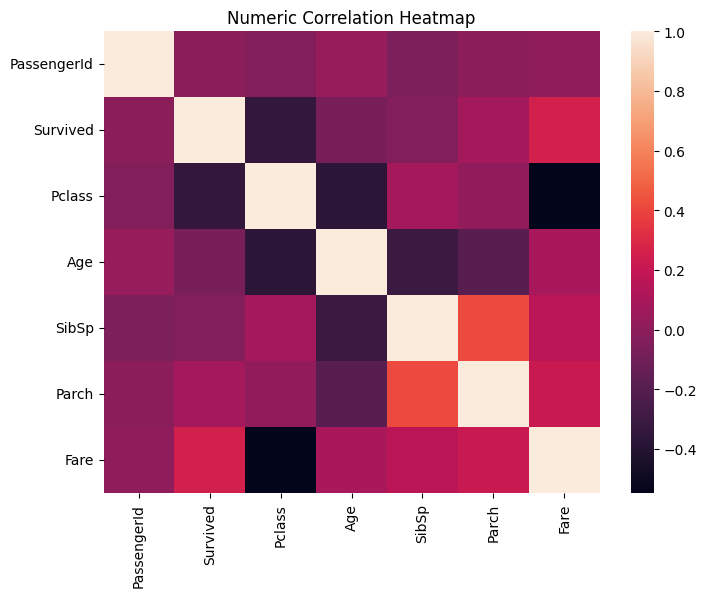

In [8]:
# Use your EDA class here
eda = ml_utils.EDA(df)

eda.overview()
eda.missing_summary()
eda.target_summary(target="Survived")
eda.numeric_summary()

# Optional quick plot(s)
eda.corr_heatmap()



### EDA Questions (answer in markdown)
- What columns have the most missing values?
  - Cabin has the most missing values
- Which columns are categorical vs numeric?
  - Sex and age
- What is the baseline survival rate?
  - The basleine survival rate is 38%
- What cleaning steps do you expect before modeling?
  - Handle missing values, fix data types, and remove duplicates if theres any
  

## Part B — Build Model with Pipeline by Tuning HP

In [12]:
# Basic cleanup: choose features and target
target = "Survived"
# --- Feature Engineering (simple but helpful) ---
# 1) Family size and 'is alone'
if "SibSp" in df.columns and "Parch" in df.columns:
    df["FamilySize"] = df["SibSp"].fillna(0) + df["Parch"].fillna(0) + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# 2) Title from Name (Mr, Mrs, Miss, etc.)
if "Name" in df.columns:
    df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).fillna("Unknown")
    # group rare titles to keep one-hot small
    common = df["Title"].value_counts().head(6).index
    df["Title"] = df["Title"].where(df["Title"].isin(common), "Rare")

# Drop very messy text columns (you can justify in reflection)
drop_extra = [c for c in ["Name","Ticket","Cabin"] if c in df.columns]
df = df.drop(columns=drop_extra)

# Drop columns that are often identifiers/leakage/too messy (you can justify changes)
drop_cols = ["PassengerId"] if "PassengerId" in df.columns else []
X = df.drop(columns=[target] + drop_cols)
y = df[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
692,3,male,NaN,0,0,56.4958,S,1,1,Mr
481,2,male,NaN,0,0,0.0000,S,1,1,Mr
527,1,male,NaN,0,0,221.7792,S,1,1,Mr
855,3,female,18.0,0,1,9.3500,S,2,0,Mrs
801,2,female,31.0,1,1,26.2500,S,3,0,Mrs


In [11]:
required = ["X_train", "X_test", "y_train", "y_test"]
missing = [v for v in required if v not in globals()]
print("Missing:", missing)


Missing: ['X_train', 'X_test', 'y_train', 'y_test']


In [13]:
# Identify numeric vs categorical columns from TRAIN only
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]
# Build preprocessing pipelines: impute missing values + scale numeric + one-hot encode categorical
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop",
)


In [14]:
# Candidate pipelines
pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000)),
])

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42)),
])

# Hyperparameter grids (edit/expand as needed)
param_grid_lr = {
    "model__C": [0.1, 1.0, 10.0],
}

param_grid_rf = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 10],
}


In [15]:
# Grid search (run both and pick best by CV score)
gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring="accuracy", n_jobs=-1)
gs_lr.fit(X_train, y_train)

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring="accuracy", n_jobs=-1)
gs_rf.fit(X_train, y_train)

best_search = gs_lr if gs_lr.best_score_ >= gs_rf.best_score_ else gs_rf
best_model = best_search.best_estimator_

print("Best CV score:", best_search.best_score_)
print("Best params:", best_search.best_params_)


Best CV score: 0.823076923076923
Best params: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 500}


In [16]:
# Evaluate on test set
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", acc)
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Test Accuracy: 0.8268156424581006

Confusion matrix:
 [[97 13]
 [18 51]]

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



In [17]:
# Evaluate on test set
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", acc)
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Test Accuracy: 0.8268156424581006

Confusion matrix:
 [[97 13]
 [18 51]]

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.80      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



### Reflection (answer in markdown)
- Which engineered features helped the most (your guess + evidence)?
  - Title and IsAlone/FamilySize likely helped most, because they capture social status and whether someone had family support
- Which model won (LR vs RF) and why might that happen?
  - The model with the higher GridSearch CV score won, because it can learn non-linear patterns and feature interactions that LR can’t.
- If you had 1 more hour, what would you try next?
  - Id extract Deck from Cabin instead of dropping it and then try a boosted
  ExtraTrees model with a slightly wider hyperparameter search to see if performance improves.